# Import modules

In [2]:
!pip install beautifulsoup4
!pip install lxml




[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from selenium import webdriver
import main
import seaborn as sns
%load_ext autoreload
%autoreload 2

# Get match data

If you get the following exception, try running the cell again:<br>
`WebDriverException: Message: unknown error: cannot determine loading status
from no such window`

In [55]:
if __name__ == "__main__":
    driver = webdriver.Firefox()
    
# whoscored match centre url of the required match (Example: Barcelona vs Sevilla)
url = "https://www.whoscored.com/matches/1903851/live/"
match_data = main.getMatchData(driver, url, close_window=True)

# Match dataframe containing info about the match
matches_df = main.createMatchesDF(match_data)

# Events dataframe      
events_df = main.createEventsDF(match_data)

# match Id
matchId = match_data['matchId']

# Information about respective teams as dictionary
home_data = matches_df['home'][matchId]
away_data = matches_df['away'][matchId]

Region: Netherlands, League: Eredivisie, Season: 2025/2026, Match Id: 1903851


In [56]:
matches_df

,attendance,venueName,startTime,startDate,score,home,away,referee
matchId,,,,,,,,
1903851,10440,Fortuna Sittard Stadion,2025-12-21T15:45:00,2025-12-21T00:00:00,4 : 3,"[{'teamId': 242, 'formations': [{'formationId'...","[{'teamId': 243, 'formations': [{'formationId'...",NaN
1903851,10440,Fortuna Sittard Stadion,2025-12-21T15:45:00,2025-12-21T00:00:00,4 : 3,NaN,NaN,NaN
1903851,10440,Fortuna Sittard Stadion,2025-12-21T15:45:00,2025-12-21T00:00:00,4 : 3,NaN,NaN,NaN
1903851,10440,Fortuna Sittard Stadion,2025-12-21T15:45:00,2025-12-21T00:00:00,4 : 3,NaN,NaN,NaN
1903851,10440,Fortuna Sittard Stadion,2025-12-21T15:45:00,2025-12-21T00:00:00,4 : 3,NaN,NaN,NaN
1903851,10440,Fortuna Sittard Stadion,2025-12-21T15:45:00,2025-12-21T00:00:00,4 : 3,NaN,NaN,Marc Nagtegaal
1903851,10440,Fortuna Sittard Stadion,2025-12-21T15:45:00,2025-12-21T00:00:00,4 : 3,NaN,NaN,NaN
1903851,10440,Fortuna Sittard Stadion,2025-12-21T15:45:00,2025-12-21T00:00:00,4 : 3,NaN,NaN,NaN
1903851,10440,Fortuna Sittard Stadion,2025-12-21T15:45:00,2025-12-21T00:00:00,4 : 3,NaN,NaN,NaN


In [57]:
events_df

,id,eventId,minute,second,teamId,h_a,x,y,expandedMinute,period,...,penaltyShootoutSaved,penaltyShootoutSavedGK,penaltyShootoutConcededGK,throwIn,subOn,subOff,defensiveThird,midThird,finalThird,pos
0,2.885395e+09,2,0,0.0,243,a,0.0,0.0,0,FirstHalf,...,False,False,False,False,False,False,False,False,False,False
1,2.885395e+09,2,0,0.0,242,h,0.0,0.0,0,FirstHalf,...,False,False,False,False,False,False,False,False,False,False
2,2.885395e+09,3,0,0.0,243,a,50.0,49.9,0,FirstHalf,...,False,False,False,False,False,False,True,False,False,True
3,2.885395e+09,4,0,2.0,243,a,31.2,52.4,0,FirstHalf,...,False,False,False,False,False,False,False,True,False,True
4,2.885395e+09,5,0,6.0,243,a,36.7,79.6,0,FirstHalf,...,False,False,False,False,False,False,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1360,2.885482e+09,874,99,50.0,243,a,0.0,0.0,103,SecondHalf,...,False,False,False,False,False,False,False,False,False,False
1361,2.885482e+09,637,0,0.0,242,h,0.0,0.0,13,PostGame,...,False,False,False,False,False,False,False,False,False,False
1362,2.885482e+09,875,0,0.0,243,a,0.0,0.0,13,PostGame,...,False,False,False,False,False,False,False,False,False,False
1363,2.885341e+09,1,0,0.0,242,h,0.0,0.0,0,PreMatch,...,False,False,False,False,False,False,False,False,False,False


In [61]:
from main import add_xg_to_all_events_whoscored

events_df = add_xg_to_all_events_whoscored(
    df_events=events_df,
    model_path="xg_model.joblib",
    encoders_path="label_encoders_xgmodel.joblib",
    xg_col="xG_model"
)

In [64]:
team_summary = (
    events_df
    .groupby("teamId")
    .agg(
        shots=("isShot", "sum"),
        goals=("isGoal", "sum"),
        xG=("xG_model", "sum")
    )
    .reset_index()
)

team_summary


,teamId,shots,goals,xG
0,242,15,4,2.540989
1,243,21,3,4.138881


# Calculate EPV for successful passes

In [16]:
events_df = main.addEpvToDataFrame(events_df)

# Get data for multiple matches

## getting competition urls

In [8]:
league_urls = main.getLeagueUrls()
# Updated league urls format: {country-league_name: url}
league_urls

ElementClickInterceptedException: Message: Element <button id="All-Tournaments-btn" class="MainNavigation-module_tournamentDropdownToggle__3EF-q"> is not clickable at point (451,115) because another element <img class="webpush-swal2-image" src="https://s3.xtremepush.com/campaign/2333_nWdShYWBKJDYIFdUEiOwMIwtnxcWkG_N.png"> obscures it
Stacktrace:
RemoteError@chrome://remote/content/shared/RemoteError.sys.mjs:8:8
WebDriverError@chrome://remote/content/shared/webdriver/Errors.sys.mjs:202:5
ElementClickInterceptedError@chrome://remote/content/shared/webdriver/Errors.sys.mjs:354:5
webdriverClickElement@chrome://remote/content/marionette/interaction.sys.mjs:175:11
interaction.clickElement@chrome://remote/content/marionette/interaction.sys.mjs:134:11
clickElement@chrome://remote/content/marionette/actors/MarionetteCommandsChild.sys.mjs:328:29
receiveMessage@chrome://remote/content/marionette/actors/MarionetteCommandsChild.sys.mjs:210:31


In [9]:
league_urls = {'afrique-caf-champions-league': 'https://1xbet.whoscored.com/regions/248/tournaments/290/afrique-caf-champions-league',
 'afrique-caf-super-cup': 'https://1xbet.whoscored.com/regions/248/tournaments/573/afrique-caf-super-cup',
 'afrique-africa-cup-of-nations-qualification': 'https://1xbet.whoscored.com/regions/248/tournaments/747/afrique-africa-cup-of-nations-qualification',
 'afrique-african-nations-championship-qualification': 'https://1xbet.whoscored.com/regions/248/tournaments/754/afrique-african-nations-championship-qualification',
 'afrique-caf-champions-league-qualification': 'https://1xbet.whoscored.com/regions/248/tournaments/762/afrique-caf-champions-league-qualification',
 'afrique-caf-confederations-cup': 'https://1xbet.whoscored.com/regions/248/tournaments/574/afrique-caf-confederations-cup',
 'afrique-cecafa-senior-challenge-cup': 'https://1xbet.whoscored.com/regions/248/tournaments/505/afrique-cecafa-senior-challenge-cup',
 'asia-gulf-cup': 'https://1xbet.whoscored.com/regions/249/tournaments/241/asia-gulf-cup',
 'asia-east-asian-championship': 'https://1xbet.whoscored.com/regions/249/tournaments/212/asia-east-asian-championship',
 'asia-aff-championship': 'https://1xbet.whoscored.com/regions/249/tournaments/490/asia-aff-championship',
 'asia-afc-champions-league': 'https://1xbet.whoscored.com/regions/249/tournaments/287/asia-afc-champions-league',
 'asia-afc-cup': 'https://1xbet.whoscored.com/regions/249/tournaments/575/asia-afc-cup',
 'asia-afc-champions-league-elite-qualification': 'https://1xbet.whoscored.com/regions/249/tournaments/763/asia-afc-champions-league-elite-qualification',
 'asia-afc-u23-asian-cup': 'https://1xbet.whoscored.com/regions/249/tournaments/644/asia-afc-u23-asian-cup',
 'asia-asean-championship-qualification': 'https://1xbet.whoscored.com/regions/249/tournaments/753/asia-asean-championship-qualification',
 'asia-asian-cup-qualification': 'https://1xbet.whoscored.com/regions/249/tournaments/748/asia-asian-cup-qualification',
 'asia-premier-league-asia-trophy': 'https://1xbet.whoscored.com/regions/249/tournaments/635/asia-premier-league-asia-trophy',
 'europe-champions-league': 'https://1xbet.whoscored.com/regions/250/tournaments/12/europe-champions-league',
 'europe-europa-league': 'https://1xbet.whoscored.com/regions/250/tournaments/30/europe-europa-league',
 'europe-european-championship-qualification': 'https://1xbet.whoscored.com/regions/250/tournaments/751/europe-european-championship-qualification',
 'europe-uefa-super-cup': 'https://1xbet.whoscored.com/regions/250/tournaments/62/europe-uefa-super-cup',
 'europe-conference-league': 'https://1xbet.whoscored.com/regions/250/tournaments/715/europe-conference-league',
 'europe-women-s-champions-league': 'https://1xbet.whoscored.com/regions/250/tournaments/741/europe-women-s-champions-league',
 'europe-champions-league-qualification': 'https://1xbet.whoscored.com/regions/250/tournaments/757/europe-champions-league-qualification',
 'europe-europa-league-qualification': 'https://1xbet.whoscored.com/regions/250/tournaments/759/europe-europa-league-qualification',
 'europe-conference-league-qualification': 'https://1xbet.whoscored.com/regions/250/tournaments/760/europe-conference-league-qualification',
 'europe-uefa-youth-league': 'https://1xbet.whoscored.com/regions/250/tournaments/680/europe-uefa-youth-league',
 'europe-the-atlantic-cup': 'https://1xbet.whoscored.com/regions/250/tournaments/613/europe-the-atlantic-cup',
 'international-european-championship': 'https://1xbet.whoscored.com/regions/247/tournaments/124/international-european-championship',
 'international-copa-america': 'https://1xbet.whoscored.com/regions/247/tournaments/94/international-copa-america',
 'international-fifa-world-cup': 'https://1xbet.whoscored.com/regions/247/tournaments/36/international-fifa-world-cup',
 'international-africa-cup-of-nations': 'https://1xbet.whoscored.com/regions/247/tournaments/104/international-africa-cup-of-nations',
 'international-uefa-women-s-euro': 'https://1xbet.whoscored.com/regions/247/tournaments/775/international-uefa-women-s-euro',
 'international-fifa-women-s-world-cup': 'https://1xbet.whoscored.com/regions/247/tournaments/738/international-fifa-women-s-world-cup',
 'international-uefa-nations-league-a': 'https://1xbet.whoscored.com/regions/247/tournaments/683/international-uefa-nations-league-a',
 'international-uefa-nations-league-b': 'https://1xbet.whoscored.com/regions/247/tournaments/684/international-uefa-nations-league-b',
 'international-uefa-nations-league-c': 'https://1xbet.whoscored.com/regions/247/tournaments/685/international-uefa-nations-league-c',
 'international-uefa-nations-league-d': 'https://1xbet.whoscored.com/regions/247/tournaments/686/international-uefa-nations-league-d',
 'international-world-cup-qualification-uefa': 'https://1xbet.whoscored.com/regions/247/tournaments/721/international-world-cup-qualification-uefa',
 'international-world-cup-qualification-conmebol': 'https://1xbet.whoscored.com/regions/247/tournaments/719/international-world-cup-qualification-conmebol',
 'international-world-cup-qualification-caf': 'https://1xbet.whoscored.com/regions/247/tournaments/716/international-world-cup-qualification-caf',
 'international-world-cup-qualification-concacaf': 'https://1xbet.whoscored.com/regions/247/tournaments/717/international-world-cup-qualification-concacaf',
 'international-world-cup-qualification-afc': 'https://1xbet.whoscored.com/regions/247/tournaments/718/international-world-cup-qualification-afc',
 'international-asian-cup': 'https://1xbet.whoscored.com/regions/247/tournaments/166/international-asian-cup',
 'international-euro-u-21': 'https://1xbet.whoscored.com/regions/247/tournaments/123/international-euro-u-21',
 'international-fifa-club-world-cup': 'https://1xbet.whoscored.com/regions/247/tournaments/67/international-fifa-club-world-cup',
 'international-uefa-nations-league-a-qualification': 'https://1xbet.whoscored.com/regions/247/tournaments/768/international-uefa-nations-league-a-qualification',
 'international-uefa-nations-league-b-qualification': 'https://1xbet.whoscored.com/regions/247/tournaments/769/international-uefa-nations-league-b-qualification',
 'international-euro-u-19': 'https://1xbet.whoscored.com/regions/247/tournaments/165/international-euro-u-19',
 'international-int-friendly': 'https://1xbet.whoscored.com/regions/247/tournaments/27/international-int-friendly',
 'international-summer-olympics': 'https://1xbet.whoscored.com/regions/247/tournaments/177/international-summer-olympics',
 'international-toulon-tournament': 'https://1xbet.whoscored.com/regions/247/tournaments/203/international-toulon-tournament',
 'international-world-championship-u-20': 'https://1xbet.whoscored.com/regions/247/tournaments/144/international-world-championship-u-20',
 'international-african-nations-championship': 'https://1xbet.whoscored.com/regions/247/tournaments/563/international-african-nations-championship',
 'international-concacaf-nations-league': 'https://1xbet.whoscored.com/regions/247/tournaments/689/international-concacaf-nations-league',
 'international-club-friendlies': 'https://1xbet.whoscored.com/regions/247/tournaments/57/international-club-friendlies',
 'international-confederations-cup': 'https://1xbet.whoscored.com/regions/247/tournaments/89/international-confederations-cup',
 'international-africa-cup-of-nations-u20': 'https://1xbet.whoscored.com/regions/247/tournaments/656/international-africa-cup-of-nations-u20',
 'international-euro-u-17': 'https://1xbet.whoscored.com/regions/247/tournaments/201/international-euro-u-17',
 'international-friendly-u-21': 'https://1xbet.whoscored.com/regions/247/tournaments/244/international-friendly-u-21',
 'international-world-championship-u-17': 'https://1xbet.whoscored.com/regions/247/tournaments/219/international-world-championship-u-17',
 'international-euro-u21-qualification': 'https://1xbet.whoscored.com/regions/247/tournaments/736/international-euro-u21-qualification',
 'international-ofc-u19-championship': 'https://1xbet.whoscored.com/regions/247/tournaments/690/international-ofc-u19-championship',
 'amérique-centrale-et-du-nord-concacaf-gold-cup': 'https://1xbet.whoscored.com/regions/264/tournaments/131/amérique-centrale-et-du-nord-concacaf-gold-cup',
 'amérique-centrale-et-du-nord-concacaf-champions-cup': 'https://1xbet.whoscored.com/regions/264/tournaments/222/amérique-centrale-et-du-nord-concacaf-champions-cup',
 'amérique-centrale-et-du-nord-leagues-cup': 'https://1xbet.whoscored.com/regions/264/tournaments/740/amérique-centrale-et-du-nord-leagues-cup',
 'amérique-centrale-et-du-nord-concacaf-league': 'https://1xbet.whoscored.com/regions/264/tournaments/668/amérique-centrale-et-du-nord-concacaf-league',
 'amérique-centrale-et-du-nord-concacaf-gold-cup-qualification': 'https://1xbet.whoscored.com/regions/264/tournaments/752/amérique-centrale-et-du-nord-concacaf-gold-cup-qualification',
 'amérique-centrale-et-du-nord-concacaf-nations-league-qualification': 'https://1xbet.whoscored.com/regions/264/tournaments/756/amérique-centrale-et-du-nord-concacaf-nations-league-qualification',
 'amérique-centrale-et-du-nord-cfu-club-champions-cup': 'https://1xbet.whoscored.com/regions/264/tournaments/462/amérique-centrale-et-du-nord-cfu-club-champions-cup',
 'amérique-centrale-et-du-nord-concacaf-championship-u20': 'https://1xbet.whoscored.com/regions/264/tournaments/655/amérique-centrale-et-du-nord-concacaf-championship-u20',
 'amérique-du-sud-copa-libertadores': 'https://1xbet.whoscored.com/regions/265/tournaments/105/amérique-du-sud-copa-libertadores',
 'amérique-du-sud-copa-sudamericana': 'https://1xbet.whoscored.com/regions/265/tournaments/146/amérique-du-sud-copa-sudamericana',
 'amérique-du-sud-recopa-sudamericana': 'https://1xbet.whoscored.com/regions/265/tournaments/271/amérique-du-sud-recopa-sudamericana',
 'amérique-du-sud-copa-libertadores-qualification': 'https://1xbet.whoscored.com/regions/265/tournaments/761/amérique-du-sud-copa-libertadores-qualification',
 'amérique-du-sud-copa-sudamericana-qualification': 'https://1xbet.whoscored.com/regions/265/tournaments/764/amérique-du-sud-copa-sudamericana-qualification',
 'albania-kategoria-superiore': 'https://1xbet.whoscored.com/regions/3/tournaments/182/albania-kategoria-superiore',
 'albania-kategoria-superiore-qualification': 'https://1xbet.whoscored.com/regions/3/tournaments/451/albania-kategoria-superiore-qualification',
 'albania-kupa-e-shqipërisë': 'https://1xbet.whoscored.com/regions/3/tournaments/618/albania-kupa-e-shqipërisë',
 'algeria-ligue-professionnelle-1': 'https://1xbet.whoscored.com/regions/4/tournaments/281/algeria-ligue-professionnelle-1',
 'andorra-andorran-cup': 'https://1xbet.whoscored.com/regions/6/tournaments/619/andorra-andorran-cup',
 'andorra-primera-divisio': 'https://1xbet.whoscored.com/regions/6/tournaments/142/andorra-primera-divisio',
 'andorra-primera-divisio-qualification': 'https://1xbet.whoscored.com/regions/6/tournaments/526/andorra-primera-divisio-qualification',
 'argentina-liga-profesional': 'https://1xbet.whoscored.com/regions/11/tournaments/68/argentina-liga-profesional',
 'argentina-copa-de-la-superliga': 'https://1xbet.whoscored.com/regions/11/tournaments/697/argentina-copa-de-la-superliga',
 'argentina-cup': 'https://1xbet.whoscored.com/regions/11/tournaments/504/argentina-cup',
 'argentina-super-cup': 'https://1xbet.whoscored.com/regions/11/tournaments/541/argentina-super-cup',
 'argentina-primera-b-nacional': 'https://1xbet.whoscored.com/regions/11/tournaments/317/argentina-primera-b-nacional',
 'argentina-argentina-4': 'https://1xbet.whoscored.com/regions/11/tournaments/605/argentina-argentina-4',
 'argentina-primera-b-metropolitana': 'https://1xbet.whoscored.com/regions/11/tournaments/463/argentina-primera-b-metropolitana',
 'armenia-cup': 'https://1xbet.whoscored.com/regions/12/tournaments/256/armenia-cup',
 'armenia-premier-league': 'https://1xbet.whoscored.com/regions/12/tournaments/156/armenia-premier-league',
 'armenia-super-cup': 'https://1xbet.whoscored.com/regions/12/tournaments/270/armenia-super-cup',
 'australia-a-league': 'https://1xbet.whoscored.com/regions/14/tournaments/194/australia-a-league',
 'australia-australia-2': 'https://1xbet.whoscored.com/regions/14/tournaments/312/australia-australia-2',
 'australia-australia-cup': 'https://1xbet.whoscored.com/regions/14/tournaments/577/australia-australia-cup',
 'australia-australia-4': 'https://1xbet.whoscored.com/regions/14/tournaments/612/australia-australia-4',
 'australia-npl': 'https://1xbet.whoscored.com/regions/14/tournaments/567/australia-npl',
 'austria-bundesliga': 'https://1xbet.whoscored.com/regions/15/tournaments/32/austria-bundesliga',
 'austria-erste-liga': 'https://1xbet.whoscored.com/regions/15/tournaments/53/austria-erste-liga',
 'austria-stiegl-cup': 'https://1xbet.whoscored.com/regions/15/tournaments/83/austria-stiegl-cup',
 'austria-regionalliga': 'https://1xbet.whoscored.com/regions/15/tournaments/441/austria-regionalliga',
 'azerbaijan-premier-league': 'https://1xbet.whoscored.com/regions/16/tournaments/173/azerbaijan-premier-league',
 'azerbaijan-azerbaijan-cup-1': 'https://1xbet.whoscored.com/regions/16/tournaments/615/azerbaijan-azerbaijan-cup-1',
 'bahrain-1-division': 'https://1xbet.whoscored.com/regions/18/tournaments/302/bahrain-1-division',
 'belarus-premier-league': 'https://1xbet.whoscored.com/regions/21/tournaments/157/belarus-premier-league',
 'belarus-super-cup': 'https://1xbet.whoscored.com/regions/21/tournaments/657/belarus-super-cup',
 'belarus-belarus-cup-1': 'https://1xbet.whoscored.com/regions/21/tournaments/620/belarus-belarus-cup-1',
 'belarus-premier-league-qualification': 'https://1xbet.whoscored.com/regions/21/tournaments/480/belarus-premier-league-qualification',
 'belgium-cup': 'https://1xbet.whoscored.com/regions/22/tournaments/28/belgium-cup',
 'belgium-jupiler-pro-league': 'https://1xbet.whoscored.com/regions/22/tournaments/18/belgium-jupiler-pro-league',
 'belgium-super-cup': 'https://1xbet.whoscored.com/regions/22/tournaments/117/belgium-super-cup',
 'belgium-play-off': 'https://1xbet.whoscored.com/regions/22/tournaments/161/belgium-play-off',
 'belgium-second-division': 'https://1xbet.whoscored.com/regions/22/tournaments/137/belgium-second-division',
 'belgium-3-division': 'https://1xbet.whoscored.com/regions/22/tournaments/459/belgium-3-division',
 'bolivia-liga-de-fútbol-profesional': 'https://1xbet.whoscored.com/regions/27/tournaments/255/bolivia-liga-de-fútbol-profesional',
 'bolivia-primera-division-qualification': 'https://1xbet.whoscored.com/regions/27/tournaments/528/bolivia-primera-division-qualification',
 'bosnia-herzegovina-1-division': 'https://1xbet.whoscored.com/regions/28/tournaments/404/bosnia-herzegovina-1-division',
 'bosnia-herzegovina-bosnia-herzegovina-cup-1': 'https://1xbet.whoscored.com/regions/28/tournaments/616/bosnia-herzegovina-bosnia-herzegovina-cup-1',
 'bosnia-herzegovina-premier-league': 'https://1xbet.whoscored.com/regions/28/tournaments/174/bosnia-herzegovina-premier-league',
 'brazil-brasileirão': 'https://1xbet.whoscored.com/regions/31/tournaments/95/brazil-brasileirão',
 'brazil-cup': 'https://1xbet.whoscored.com/regions/31/tournaments/383/brazil-cup',
 'brazil-serie-b': 'https://1xbet.whoscored.com/regions/31/tournaments/269/brazil-serie-b',
 'brazil-serie-c': 'https://1xbet.whoscored.com/regions/31/tournaments/321/brazil-serie-c',
 'brazil-cup-nordeste': 'https://1xbet.whoscored.com/regions/31/tournaments/564/brazil-cup-nordeste',
 'brazil-sao-paulo-youth-cup': 'https://1xbet.whoscored.com/regions/31/tournaments/654/brazil-sao-paulo-youth-cup',
 'brazil-serie-d': 'https://1xbet.whoscored.com/regions/31/tournaments/570/brazil-serie-d',
 'bulgaria-a-pfg': 'https://1xbet.whoscored.com/regions/34/tournaments/119/bulgaria-a-pfg',
 'bulgaria-b-pfg': 'https://1xbet.whoscored.com/regions/34/tournaments/398/bulgaria-b-pfg',
 'bulgaria-cup': 'https://1xbet.whoscored.com/regions/34/tournaments/143/bulgaria-cup',
 'bulgaria-super-cup': 'https://1xbet.whoscored.com/regions/34/tournaments/169/bulgaria-super-cup',
 'bulgaria-first-professional-league-qualification': 'https://1xbet.whoscored.com/regions/34/tournaments/646/bulgaria-first-professional-league-qualification',
 'cameroon-1-division': 'https://1xbet.whoscored.com/regions/38/tournaments/247/cameroon-1-division',
 'canada-championship': 'https://1xbet.whoscored.com/regions/39/tournaments/735/canada-championship',
 'canada-csl': 'https://1xbet.whoscored.com/regions/39/tournaments/363/canada-csl',
 'chile-clausura': 'https://1xbet.whoscored.com/regions/44/tournaments/147/chile-clausura',
 'chile-cup': 'https://1xbet.whoscored.com/regions/44/tournaments/395/chile-cup',
 'chile-super-cup': 'https://1xbet.whoscored.com/regions/44/tournaments/554/chile-super-cup',
 'china-super-league': 'https://1xbet.whoscored.com/regions/45/tournaments/162/china-super-league',
 'china-cup': 'https://1xbet.whoscored.com/regions/45/tournaments/640/china-cup',
 'china-super-cup': 'https://1xbet.whoscored.com/regions/45/tournaments/591/china-super-cup',
 'colombia-categoria-primera-a': 'https://1xbet.whoscored.com/regions/48/tournaments/193/colombia-categoria-primera-a',
 'colombia-colombia-cup-1': 'https://1xbet.whoscored.com/regions/48/tournaments/590/colombia-colombia-cup-1',
 'costa-rica-liga-de-ascenso': 'https://1xbet.whoscored.com/regions/53/tournaments/425/costa-rica-liga-de-ascenso',
 'costa-rica-primera-division': 'https://1xbet.whoscored.com/regions/53/tournaments/238/costa-rica-primera-division',
 'croatia-prva-hnl': 'https://1xbet.whoscored.com/regions/55/tournaments/82/croatia-prva-hnl',
 'croatia-super-cup': 'https://1xbet.whoscored.com/regions/55/tournaments/133/croatia-super-cup',
 'croatia-2-division': 'https://1xbet.whoscored.com/regions/55/tournaments/401/croatia-2-division',
 'croatia-cup': 'https://1xbet.whoscored.com/regions/55/tournaments/109/croatia-cup',
 'cyprus-2-division': 'https://1xbet.whoscored.com/regions/57/tournaments/402/cyprus-2-division',
 'cyprus-cup': 'https://1xbet.whoscored.com/regions/57/tournaments/236/cyprus-cup',
 'cyprus-first-division': 'https://1xbet.whoscored.com/regions/57/tournaments/185/cyprus-first-division',
 'cyprus-super-cup': 'https://1xbet.whoscored.com/regions/57/tournaments/283/cyprus-super-cup',
 'czech-republic-gambrinus-league': 'https://1xbet.whoscored.com/regions/58/tournaments/78/czech-republic-gambrinus-league',
 'czech-republic-super-cup': 'https://1xbet.whoscored.com/regions/58/tournaments/455/czech-republic-super-cup',
 'czech-republic-cup': 'https://1xbet.whoscored.com/regions/58/tournaments/84/czech-republic-cup',
 'czech-republic-druha-league': 'https://1xbet.whoscored.com/regions/58/tournaments/234/czech-republic-druha-league',
 'denmark-superliga': 'https://1xbet.whoscored.com/regions/59/tournaments/1/denmark-superliga',
 'denmark-1-division': 'https://1xbet.whoscored.com/regions/59/tournaments/34/denmark-1-division',
 'denmark-2-division': 'https://1xbet.whoscored.com/regions/59/tournaments/35/denmark-2-division',
 'denmark-cup': 'https://1xbet.whoscored.com/regions/59/tournaments/39/denmark-cup',
 'ecuador-serie-a': 'https://1xbet.whoscored.com/regions/63/tournaments/192/ecuador-serie-a',
 'egypt-premier-league': 'https://1xbet.whoscored.com/regions/64/tournaments/277/egypt-premier-league',
 'el-salvador-primera-division': 'https://1xbet.whoscored.com/regions/65/tournaments/250/el-salvador-primera-division',
 'england-community-shield': 'https://1xbet.whoscored.com/regions/252/tournaments/96/england-community-shield',
 'england-premier-league': 'https://1xbet.whoscored.com/regions/252/tournaments/2/england-premier-league',
 'england-fa-cup': 'https://1xbet.whoscored.com/regions/252/tournaments/26/england-fa-cup',
 'england-league-cup': 'https://1xbet.whoscored.com/regions/252/tournaments/29/england-league-cup',
 'england-championship': 'https://1xbet.whoscored.com/regions/252/tournaments/7/england-championship',
 'england-league-one': 'https://1xbet.whoscored.com/regions/252/tournaments/8/england-league-one',
 'england-women-s-super-league': 'https://1xbet.whoscored.com/regions/252/tournaments/739/england-women-s-super-league',
 'england-league-two': 'https://1xbet.whoscored.com/regions/252/tournaments/9/england-league-two',
 'england-fa-trophy': 'https://1xbet.whoscored.com/regions/252/tournaments/479/england-fa-trophy',
 'england-national-league-premier': 'https://1xbet.whoscored.com/regions/252/tournaments/70/england-national-league-premier',
 'england-papa-john-s-trophy': 'https://1xbet.whoscored.com/regions/252/tournaments/23/england-papa-john-s-trophy',
 'england-national-league': 'https://1xbet.whoscored.com/regions/252/tournaments/314/england-national-league',
 'england-professional-development-league': 'https://1xbet.whoscored.com/regions/252/tournaments/389/england-professional-development-league',
 'england-regional-league': 'https://1xbet.whoscored.com/regions/252/tournaments/315/england-regional-league',
 'estonia-cup': 'https://1xbet.whoscored.com/regions/68/tournaments/621/estonia-cup',
 'estonia-esiliiga': 'https://1xbet.whoscored.com/regions/68/tournaments/405/estonia-esiliiga',
 'estonia-meistriliiga': 'https://1xbet.whoscored.com/regions/68/tournaments/148/estonia-meistriliiga',
 'estonia-super-cup': 'https://1xbet.whoscored.com/regions/68/tournaments/385/estonia-super-cup',
 'faroe-islands-cup': 'https://1xbet.whoscored.com/regions/71/tournaments/622/faroe-islands-cup',
 'faroe-islands-formuladeildin': 'https://1xbet.whoscored.com/regions/71/tournaments/160/faroe-islands-formuladeildin',
 'finland-cup': 'https://1xbet.whoscored.com/regions/73/tournaments/51/finland-cup',
 'finland-kakkonen': 'https://1xbet.whoscored.com/regions/73/tournaments/319/finland-kakkonen',
 'finland-playoff': 'https://1xbet.whoscored.com/regions/73/tournaments/100/finland-playoff',
 'finland-veikkausliiga': 'https://1xbet.whoscored.com/regions/73/tournaments/43/finland-veikkausliiga',
 'finland-ykkonen': 'https://1xbet.whoscored.com/regions/73/tournaments/202/finland-ykkonen',
 'france-ligue-1': 'https://1xbet.whoscored.com/regions/74/tournaments/22/france-ligue-1',
 'france-coupe-de-france': 'https://1xbet.whoscored.com/regions/74/tournaments/16/france-coupe-de-france',
 'france-trophée-des-champions': 'https://1xbet.whoscored.com/regions/74/tournaments/54/france-trophée-des-champions',
 'france-ligue-1-qualification': 'https://1xbet.whoscored.com/regions/74/tournaments/660/france-ligue-1-qualification',
 'france-ligue-2': 'https://1xbet.whoscored.com/regions/74/tournaments/37/france-ligue-2',
 'france-division-1-feminine': 'https://1xbet.whoscored.com/regions/74/tournaments/743/france-division-1-feminine',
 'france-ligue-2-qualification': 'https://1xbet.whoscored.com/regions/74/tournaments/661/france-ligue-2-qualification',
 'france-national': 'https://1xbet.whoscored.com/regions/74/tournaments/320/france-national',
 'france-national-2': 'https://1xbet.whoscored.com/regions/74/tournaments/460/france-national-2',
 'georgia-cup': 'https://1xbet.whoscored.com/regions/80/tournaments/623/georgia-cup',
 'georgia-evronuli-liga': 'https://1xbet.whoscored.com/regions/80/tournaments/168/georgia-evronuli-liga',
 'georgia-evronuli-liga-qualification': 'https://1xbet.whoscored.com/regions/80/tournaments/507/georgia-evronuli-liga-qualification',
 'georgia-erovnuli-liga-2': 'https://1xbet.whoscored.com/regions/80/tournaments/522/georgia-erovnuli-liga-2',
 'germany-bundesliga': 'https://1xbet.whoscored.com/regions/81/tournaments/3/germany-bundesliga',
 'germany-german-super-cup': 'https://1xbet.whoscored.com/regions/81/tournaments/307/germany-german-super-cup',
 'germany-dfb-pokal': 'https://1xbet.whoscored.com/regions/81/tournaments/24/germany-dfb-pokal',
 'germany-2-bundesliga': 'https://1xbet.whoscored.com/regions/81/tournaments/6/germany-2-bundesliga',
 'germany-bundesliga-qualification': 'https://1xbet.whoscored.com/regions/81/tournaments/388/germany-bundesliga-qualification',
 'germany-frauen-bundesliga': 'https://1xbet.whoscored.com/regions/81/tournaments/745/germany-frauen-bundesliga',
 'germany-2-bundesliga-qualification': 'https://1xbet.whoscored.com/regions/81/tournaments/673/germany-2-bundesliga-qualification',
 'germany-3-liga': 'https://1xbet.whoscored.com/regions/81/tournaments/308/germany-3-liga',
 'germany-regionalliga': 'https://1xbet.whoscored.com/regions/81/tournaments/274/germany-regionalliga',
 'ghana-premier-league': 'https://1xbet.whoscored.com/regions/82/tournaments/305/ghana-premier-league',
 'gibraltar-gibraltar-cup': 'https://1xbet.whoscored.com/regions/83/tournaments/633/gibraltar-gibraltar-cup',
 'gibraltar-gibraltar-premier-league': 'https://1xbet.whoscored.com/regions/83/tournaments/632/gibraltar-gibraltar-premier-league',
 'greece-super-league': 'https://1xbet.whoscored.com/regions/84/tournaments/65/greece-super-league',
 'greece-cup': 'https://1xbet.whoscored.com/regions/84/tournaments/69/greece-cup',
 'greece-second-division': 'https://1xbet.whoscored.com/regions/84/tournaments/292/greece-second-division',
 'guatemala-liga-nacional': 'https://1xbet.whoscored.com/regions/89/tournaments/239/guatemala-liga-nacional',
 'honduras-liga-nacional': 'https://1xbet.whoscored.com/regions/97/tournaments/240/honduras-liga-nacional',
 'hong-kong-1-division': 'https://1xbet.whoscored.com/regions/98/tournaments/332/hong-kong-1-division',
 'hungary-cup': 'https://1xbet.whoscored.com/regions/99/tournaments/102/hungary-cup',
 'hungary-nb-i': 'https://1xbet.whoscored.com/regions/99/tournaments/75/hungary-nb-i',
 'hungary-nb-ii': 'https://1xbet.whoscored.com/regions/99/tournaments/419/hungary-nb-ii',
 'hungary-super-cup': 'https://1xbet.whoscored.com/regions/99/tournaments/132/hungary-super-cup',
 'iceland-1-deild': 'https://1xbet.whoscored.com/regions/100/tournaments/208/iceland-1-deild',
 'iceland-besta-deildin': 'https://1xbet.whoscored.com/regions/100/tournaments/129/iceland-besta-deildin',
 'iceland-cup': 'https://1xbet.whoscored.com/regions/100/tournaments/206/iceland-cup',
 'india-i-league': 'https://1xbet.whoscored.com/regions/101/tournaments/333/india-i-league',
 'india-indian-super-league': 'https://1xbet.whoscored.com/regions/101/tournaments/582/india-indian-super-league',
 'indonesia-super-liga': 'https://1xbet.whoscored.com/regions/102/tournaments/334/indonesia-super-liga',
 'iran-hazfi-cup': 'https://1xbet.whoscored.com/regions/103/tournaments/587/iran-hazfi-cup',
 'iran-persian-gulf-pro-league': 'https://1xbet.whoscored.com/regions/103/tournaments/279/iran-persian-gulf-pro-league',
 'iran-azadegan-league': 'https://1xbet.whoscored.com/regions/103/tournaments/534/iran-azadegan-league',
 'iraq-super-league': 'https://1xbet.whoscored.com/regions/104/tournaments/384/iraq-super-league',
 'ireland-fai-cup': 'https://1xbet.whoscored.com/regions/105/tournaments/116/ireland-fai-cup',
 'ireland-first-division': 'https://1xbet.whoscored.com/regions/105/tournaments/197/ireland-first-division',
 'ireland-league-cup': 'https://1xbet.whoscored.com/regions/105/tournaments/141/ireland-league-cup',
 'ireland-premier-division': 'https://1xbet.whoscored.com/regions/105/tournaments/113/ireland-premier-division',
 'ireland-premier-division-qualification': 'https://1xbet.whoscored.com/regions/105/tournaments/220/ireland-premier-division-qualification',
 'ireland-super-cup': 'https://1xbet.whoscored.com/regions/105/tournaments/566/ireland-super-cup',
 'israel-liga-leumit': 'https://1xbet.whoscored.com/regions/107/tournaments/181/israel-liga-leumit',
 'israel-ligat-ha-al': 'https://1xbet.whoscored.com/regions/107/tournaments/97/israel-ligat-ha-al',
 'israel-toto-cup-ligat-al': 'https://1xbet.whoscored.com/regions/107/tournaments/400/israel-toto-cup-ligat-al',
 'italy-serie-a': 'https://1xbet.whoscored.com/regions/108/tournaments/5/italy-serie-a',
 'italy-coppa-italia': 'https://1xbet.whoscored.com/regions/108/tournaments/60/italy-coppa-italia',
 'italy-supercoppa-italiana': 'https://1xbet.whoscored.com/regions/108/tournaments/64/italy-supercoppa-italiana',
 'italy-serie-b': 'https://1xbet.whoscored.com/regions/108/tournaments/19/italy-serie-b',
 'italy-serie-a-femminile': 'https://1xbet.whoscored.com/regions/108/tournaments/742/italy-serie-a-femminile',
 'italy-serie-c': 'https://1xbet.whoscored.com/regions/108/tournaments/106/italy-serie-c',
 'italy-serie-d': 'https://1xbet.whoscored.com/regions/108/tournaments/435/italy-serie-d',
 'jamaica-premier-league': 'https://1xbet.whoscored.com/regions/109/tournaments/366/jamaica-premier-league',
 'japan-j-league': 'https://1xbet.whoscored.com/regions/110/tournaments/150/japan-j-league',
 'japan-super-cup': 'https://1xbet.whoscored.com/regions/110/tournaments/248/japan-super-cup',
 'japan-cup': 'https://1xbet.whoscored.com/regions/110/tournaments/358/japan-cup',
 'japan-j-league-2': 'https://1xbet.whoscored.com/regions/110/tournaments/324/japan-j-league-2',
 'japan-league-cup': 'https://1xbet.whoscored.com/regions/110/tournaments/186/japan-league-cup',
 'japan-football-league': 'https://1xbet.whoscored.com/regions/110/tournaments/599/japan-football-league',
 'jordan-1-division': 'https://1xbet.whoscored.com/regions/112/tournaments/284/jordan-1-division',
 'kazakhstan-cup': 'https://1xbet.whoscored.com/regions/113/tournaments/614/kazakhstan-cup',
 'kazakhstan-premier-league': 'https://1xbet.whoscored.com/regions/113/tournaments/153/kazakhstan-premier-league',
 'kazakhstan-super-cup': 'https://1xbet.whoscored.com/regions/113/tournaments/604/kazakhstan-super-cup',
 'kazakhstan-premier-league-qualification': 'https://1xbet.whoscored.com/regions/113/tournaments/558/kazakhstan-premier-league-qualification',
 'kenya-premier-league': 'https://1xbet.whoscored.com/regions/114/tournaments/355/kenya-premier-league',
 'kuwait-1-division': 'https://1xbet.whoscored.com/regions/118/tournaments/293/kuwait-1-division',
 'latvia-super-cup': 'https://1xbet.whoscored.com/regions/121/tournaments/624/latvia-super-cup',
 'latvia-virsliga': 'https://1xbet.whoscored.com/regions/121/tournaments/155/latvia-virsliga',
 'lithuania-a-lyga': 'https://1xbet.whoscored.com/regions/127/tournaments/159/lithuania-a-lyga',
 'lithuania-cup': 'https://1xbet.whoscored.com/regions/127/tournaments/625/lithuania-cup',
 'lithuania-super-cup': 'https://1xbet.whoscored.com/regions/127/tournaments/593/lithuania-super-cup',
 'lithuania-a-lyga-qualification': 'https://1xbet.whoscored.com/regions/127/tournaments/652/lithuania-a-lyga-qualification',
 'luxembourg-1-division': 'https://1xbet.whoscored.com/regions/128/tournaments/172/luxembourg-1-division',
 'luxembourg-1-division-qualification': 'https://1xbet.whoscored.com/regions/128/tournaments/452/luxembourg-1-division-qualification',
 'luxembourg-luxembourg-cup-1': 'https://1xbet.whoscored.com/regions/128/tournaments/626/luxembourg-luxembourg-cup-1',
 'macedonia-cup': 'https://1xbet.whoscored.com/regions/130/tournaments/627/macedonia-cup',
 'macedonia-vtora-liga': 'https://1xbet.whoscored.com/regions/130/tournaments/396/macedonia-vtora-liga',
 'macedonia-prva-liga-qualification': 'https://1xbet.whoscored.com/regions/130/tournaments/453/macedonia-prva-liga-qualification',
 'malaysia-premier-league': 'https://1xbet.whoscored.com/regions/133/tournaments/609/malaysia-premier-league',
 'malaysia-super-liga': 'https://1xbet.whoscored.com/regions/133/tournaments/336/malaysia-super-liga',
 'malta-1-division': 'https://1xbet.whoscored.com/regions/136/tournaments/410/malta-1-division',
 'malta-cup': 'https://1xbet.whoscored.com/regions/136/tournaments/628/malta-cup',
 'malta-premier-league': 'https://1xbet.whoscored.com/regions/136/tournaments/184/malta-premier-league',
 'mexico-liga-mx': 'https://1xbet.whoscored.com/regions/142/tournaments/103/mexico-liga-mx',
 'mexico-copa-mx': 'https://1xbet.whoscored.com/regions/142/tournaments/532/mexico-copa-mx',
 'mexico-liga-de-expansión-mx': 'https://1xbet.whoscored.com/regions/142/tournaments/326/mexico-liga-de-expansión-mx',
 'mexico-liga-premier': 'https://1xbet.whoscored.com/regions/142/tournaments/588/mexico-liga-premier',
 'moldova-cup': 'https://1xbet.whoscored.com/regions/144/tournaments/629/moldova-cup',
 'moldova-super-liga': 'https://1xbet.whoscored.com/regions/144/tournaments/178/moldova-super-liga',
 'montenegro-1-division': 'https://1xbet.whoscored.com/regions/147/tournaments/235/montenegro-1-division',
 'montenegro-1-division-playoff': 'https://1xbet.whoscored.com/regions/147/tournaments/454/montenegro-1-division-playoff',
 'montenegro-2-division': 'https://1xbet.whoscored.com/regions/147/tournaments/412/montenegro-2-division',
 'montenegro-montenegro-cup-1': 'https://1xbet.whoscored.com/regions/147/tournaments/630/montenegro-montenegro-cup-1',
 'morocco-botola-pro': 'https://1xbet.whoscored.com/regions/149/tournaments/291/morocco-botola-pro',
 'morocco-botola-pro-2': 'https://1xbet.whoscored.com/regions/149/tournaments/523/morocco-botola-pro-2',
 'netherlands-eredivisie': 'https://1xbet.whoscored.com/regions/155/tournaments/13/netherlands-eredivisie',
 'netherlands-dutch-super-cup': 'https://1xbet.whoscored.com/regions/155/tournaments/120/netherlands-dutch-super-cup',
 'netherlands-knvb-cup': 'https://1xbet.whoscored.com/regions/155/tournaments/47/netherlands-knvb-cup',
 'netherlands-eredivisie-promotion-playoff': 'https://1xbet.whoscored.com/regions/155/tournaments/88/netherlands-eredivisie-promotion-playoff',
 'netherlands-eerste-divisie': 'https://1xbet.whoscored.com/regions/155/tournaments/66/netherlands-eerste-divisie',
 'netherlands-eredivisie-comeback': 'https://1xbet.whoscored.com/regions/155/tournaments/714/netherlands-eredivisie-comeback',
 'netherlands-tweede-divisie': 'https://1xbet.whoscored.com/regions/155/tournaments/457/netherlands-tweede-divisie',
 'new-zealand-premier-league': 'https://1xbet.whoscored.com/regions/158/tournaments/303/new-zealand-premier-league',
 'nigeria-1-division': 'https://1xbet.whoscored.com/regions/161/tournaments/294/nigeria-1-division',
 'n-ireland-championship': 'https://1xbet.whoscored.com/regions/258/tournaments/446/n-ireland-championship',
 'n-ireland-irish-cup': 'https://1xbet.whoscored.com/regions/258/tournaments/545/n-ireland-irish-cup',
 'n-ireland-league-cup': 'https://1xbet.whoscored.com/regions/258/tournaments/328/n-ireland-league-cup',
 'n-ireland-premiership': 'https://1xbet.whoscored.com/regions/258/tournaments/126/n-ireland-premiership',
 'n-ireland-premiership-qualification': 'https://1xbet.whoscored.com/regions/258/tournaments/329/n-ireland-premiership-qualification',
 'norway-eliteserien': 'https://1xbet.whoscored.com/regions/165/tournaments/41/norway-eliteserien',
 'norway-eliteserien-qualification': 'https://1xbet.whoscored.com/regions/165/tournaments/99/norway-eliteserien-qualification',
 'norway-1-division': 'https://1xbet.whoscored.com/regions/165/tournaments/50/norway-1-division',
 'norway-1-division-qualification': 'https://1xbet.whoscored.com/regions/165/tournaments/681/norway-1-division-qualification',
 'norway-2-division': 'https://1xbet.whoscored.com/regions/165/tournaments/200/norway-2-division',
 'norway-cup': 'https://1xbet.whoscored.com/regions/165/tournaments/52/norway-cup',
 'oman-professional-league': 'https://1xbet.whoscored.com/regions/166/tournaments/304/oman-professional-league',
 'paraguay-division-intermedia': 'https://1xbet.whoscored.com/regions/172/tournaments/422/paraguay-division-intermedia',
 'paraguay-primera-division': 'https://1xbet.whoscored.com/regions/172/tournaments/246/paraguay-primera-division',
 'peru-copa-peru': 'https://1xbet.whoscored.com/regions/173/tournaments/687/peru-copa-peru',
 'peru-primera-division': 'https://1xbet.whoscored.com/regions/173/tournaments/195/peru-primera-division',
 'poland-ekstraklasa': 'https://1xbet.whoscored.com/regions/176/tournaments/76/poland-ekstraklasa',
 'poland-super-cup': 'https://1xbet.whoscored.com/regions/176/tournaments/231/poland-super-cup',
 'poland-cup': 'https://1xbet.whoscored.com/regions/176/tournaments/101/poland-cup',
 'poland-i-liga': 'https://1xbet.whoscored.com/regions/176/tournaments/232/poland-i-liga',
 'poland-ii-liga': 'https://1xbet.whoscored.com/regions/176/tournaments/311/poland-ii-liga',
 'portugal-liga-portugal': 'https://1xbet.whoscored.com/regions/177/tournaments/21/portugal-liga-portugal',
 'portugal-super-cup': 'https://1xbet.whoscored.com/regions/177/tournaments/122/portugal-super-cup',
 'portugal-taça-de-portugal': 'https://1xbet.whoscored.com/regions/177/tournaments/11/portugal-taça-de-portugal',
 'portugal-taça-da-liga': 'https://1xbet.whoscored.com/regions/177/tournaments/275/portugal-taça-da-liga',
 'portugal-liga-3': 'https://1xbet.whoscored.com/regions/177/tournaments/414/portugal-liga-3',
 'portugal-liga-portugal-2': 'https://1xbet.whoscored.com/regions/177/tournaments/139/portugal-liga-portugal-2',
 'qatar-stars-league': 'https://1xbet.whoscored.com/regions/179/tournaments/285/qatar-stars-league',
 'qatar-stars-league-qualification': 'https://1xbet.whoscored.com/regions/179/tournaments/658/qatar-stars-league-qualification',
 'romania-cup': 'https://1xbet.whoscored.com/regions/181/tournaments/145/romania-cup',
 'romania-liga-ii': 'https://1xbet.whoscored.com/regions/181/tournaments/415/romania-liga-ii',
 'romania-super-cup': 'https://1xbet.whoscored.com/regions/181/tournaments/213/romania-super-cup',
 'romania-superliga': 'https://1xbet.whoscored.com/regions/181/tournaments/121/romania-superliga',
 'romania-superliga-qualification': 'https://1xbet.whoscored.com/regions/181/tournaments/647/romania-superliga-qualification',
 'russia-premier-league': 'https://1xbet.whoscored.com/regions/182/tournaments/77/russia-premier-league',
 'russia-cup': 'https://1xbet.whoscored.com/regions/182/tournaments/111/russia-cup',
 'russia-super-cup': 'https://1xbet.whoscored.com/regions/182/tournaments/127/russia-super-cup',
 'russia-premier-league-qualification': 'https://1xbet.whoscored.com/regions/182/tournaments/527/russia-premier-league-qualification',
 'russia-first-league': 'https://1xbet.whoscored.com/regions/182/tournaments/257/russia-first-league',
 'san-marino-campionato': 'https://1xbet.whoscored.com/regions/192/tournaments/331/san-marino-campionato',
 'saudi-arabia-pro-league': 'https://1xbet.whoscored.com/regions/194/tournaments/282/saudi-arabia-pro-league',
 'scotland-premiership': 'https://1xbet.whoscored.com/regions/253/tournaments/20/scotland-premiership',
 'scotland-fa-cup': 'https://1xbet.whoscored.com/regions/253/tournaments/10/scotland-fa-cup',
 'scotland-league-cup': 'https://1xbet.whoscored.com/regions/253/tournaments/25/scotland-league-cup',
 'scotland-premiership-qualification': 'https://1xbet.whoscored.com/regions/253/tournaments/225/scotland-premiership-qualification',
 'scotland-challenge-cup': 'https://1xbet.whoscored.com/regions/253/tournaments/118/scotland-challenge-cup',
 'scotland-championship': 'https://1xbet.whoscored.com/regions/253/tournaments/71/scotland-championship',
 'scotland-league-one': 'https://1xbet.whoscored.com/regions/253/tournaments/72/scotland-league-one',
 'scotland-league-two': 'https://1xbet.whoscored.com/regions/253/tournaments/73/scotland-league-two',
 'scotland-championship-qualification': 'https://1xbet.whoscored.com/regions/253/tournaments/676/scotland-championship-qualification',
 'scotland-league-one-qualification': 'https://1xbet.whoscored.com/regions/253/tournaments/677/scotland-league-one-qualification',
 'scotland-league-two-qualification': 'https://1xbet.whoscored.com/regions/253/tournaments/678/scotland-league-two-qualification',
 'scotland-scotland-highland-lowland': 'https://1xbet.whoscored.com/regions/253/tournaments/637/scotland-scotland-highland-lowland',
 'serbia-super-liga': 'https://1xbet.whoscored.com/regions/196/tournaments/80/serbia-super-liga',
 'serbia-cup': 'https://1xbet.whoscored.com/regions/196/tournaments/112/serbia-cup',
 'serbia-prva-liga': 'https://1xbet.whoscored.com/regions/196/tournaments/416/serbia-prva-liga',
 'singapore-cup': 'https://1xbet.whoscored.com/regions/199/tournaments/443/singapore-cup',
 'singapore-s-league': 'https://1xbet.whoscored.com/regions/199/tournaments/254/singapore-s-league',
 'slovakia-2-liga': 'https://1xbet.whoscored.com/regions/200/tournaments/323/slovakia-2-liga',
 'slovakia-fa-cup': 'https://1xbet.whoscored.com/regions/200/tournaments/107/slovakia-fa-cup',
 'slovakia-super-cup': 'https://1xbet.whoscored.com/regions/200/tournaments/130/slovakia-super-cup',
 'slovakia-super-liga': 'https://1xbet.whoscored.com/regions/200/tournaments/74/slovakia-super-liga',
 'slovenia-2-division': 'https://1xbet.whoscored.com/regions/201/tournaments/417/slovenia-2-division',
 'slovenia-cup': 'https://1xbet.whoscored.com/regions/201/tournaments/108/slovenia-cup',
 'slovenia-prva-liga': 'https://1xbet.whoscored.com/regions/201/tournaments/79/slovenia-prva-liga',
 'slovenia-prva-liga-qualification': 'https://1xbet.whoscored.com/regions/201/tournaments/272/slovenia-prva-liga-qualification',
 'south-africa-cup': 'https://1xbet.whoscored.com/regions/204/tournaments/579/south-africa-cup',
 'south-africa-premier-soccer-league': 'https://1xbet.whoscored.com/regions/204/tournaments/278/south-africa-premier-soccer-league',
 'south-africa-mtn-8-cup': 'https://1xbet.whoscored.com/regions/204/tournaments/580/south-africa-mtn-8-cup',
 'south-africa-national-first-division': 'https://1xbet.whoscored.com/regions/204/tournaments/525/south-africa-national-first-division',
 'south-korea-k-league-1': 'https://1xbet.whoscored.com/regions/260/tournaments/387/south-korea-k-league-1',
 'south-korea-k-league-1-qualification': 'https://1xbet.whoscored.com/regions/260/tournaments/560/south-korea-k-league-1-qualification',
 'south-korea-cup': 'https://1xbet.whoscored.com/regions/260/tournaments/641/south-korea-cup',
 'south-korea-k-league-2': 'https://1xbet.whoscored.com/regions/260/tournaments/418/south-korea-k-league-2',
 'south-korea-k3-league': 'https://1xbet.whoscored.com/regions/260/tournaments/634/south-korea-k3-league',
 'spain-laliga': 'https://1xbet.whoscored.com/regions/206/tournaments/4/spain-laliga',
 'spain-copa-del-rey': 'https://1xbet.whoscored.com/regions/206/tournaments/14/spain-copa-del-rey',
 'spain-supercopa-de-espana': 'https://1xbet.whoscored.com/regions/206/tournaments/61/spain-supercopa-de-espana',
 'spain-segunda-división': 'https://1xbet.whoscored.com/regions/206/tournaments/63/spain-segunda-división',
 'spain-liga-f': 'https://1xbet.whoscored.com/regions/206/tournaments/744/spain-liga-f',
 'spain-primera-division-rfef': 'https://1xbet.whoscored.com/regions/206/tournaments/318/spain-primera-division-rfef',
 'sweden-allsvenskan': 'https://1xbet.whoscored.com/regions/212/tournaments/40/sweden-allsvenskan',
 'sweden-allsvenskan-qualification': 'https://1xbet.whoscored.com/regions/212/tournaments/98/sweden-allsvenskan-qualification',
 'sweden-2-division': 'https://1xbet.whoscored.com/regions/212/tournaments/158/sweden-2-division',
 'sweden-cup': 'https://1xbet.whoscored.com/regions/212/tournaments/42/sweden-cup',
 'sweden-superettan': 'https://1xbet.whoscored.com/regions/212/tournaments/48/sweden-superettan',
 'sweden-superettan-qualification': 'https://1xbet.whoscored.com/regions/212/tournaments/310/sweden-superettan-qualification',
 'sweden-1-division': 'https://1xbet.whoscored.com/regions/212/tournaments/439/sweden-1-division',
 'sweden-1-division-qualification': 'https://1xbet.whoscored.com/regions/212/tournaments/653/sweden-1-division-qualification',
 'switzerland-super-league': 'https://1xbet.whoscored.com/regions/213/tournaments/33/switzerland-super-league',
 'switzerland-super-league-qualification': 'https://1xbet.whoscored.com/regions/213/tournaments/163/switzerland-super-league-qualification',
 'switzerland-challenge-league': 'https://1xbet.whoscored.com/regions/213/tournaments/55/switzerland-challenge-league',
 'switzerland-switzerland-cup': 'https://1xbet.whoscored.com/regions/213/tournaments/45/switzerland-switzerland-cup',
 'switzerland-1-liga': 'https://1xbet.whoscored.com/regions/213/tournaments/461/switzerland-1-liga',
 'switzerland-promotion-league': 'https://1xbet.whoscored.com/regions/213/tournaments/529/switzerland-promotion-league',
 'syria-1-division': 'https://1xbet.whoscored.com/regions/214/tournaments/296/syria-1-division',
 'taiwan-division-a': 'https://1xbet.whoscored.com/regions/215/tournaments/337/taiwan-division-a',
 'tanzania-premier-league': 'https://1xbet.whoscored.com/regions/217/tournaments/382/tanzania-premier-league',
 'thailand-thai-league': 'https://1xbet.whoscored.com/regions/218/tournaments/335/thailand-thai-league',
 'thailand-thai-league-2': 'https://1xbet.whoscored.com/regions/218/tournaments/598/thailand-thai-league-2',
 'tunisia-ligue-1': 'https://1xbet.whoscored.com/regions/224/tournaments/276/tunisia-ligue-1',
 'tunisia-ligue-i-qualification': 'https://1xbet.whoscored.com/regions/224/tournaments/663/tunisia-ligue-i-qualification',
 'turkey-super-lig': 'https://1xbet.whoscored.com/regions/225/tournaments/17/turkey-super-lig',
 'turkey-cup': 'https://1xbet.whoscored.com/regions/225/tournaments/44/turkey-cup',
 'turkey-super-cup': 'https://1xbet.whoscored.com/regions/225/tournaments/233/turkey-super-cup',
 'turkey-1-lig': 'https://1xbet.whoscored.com/regions/225/tournaments/140/turkey-1-lig',
 'turkey-2-lig': 'https://1xbet.whoscored.com/regions/225/tournaments/280/turkey-2-lig',
 'turkey-3-lig': 'https://1xbet.whoscored.com/regions/225/tournaments/327/turkey-3-lig',
 'u-a-e-pro-league': 'https://1xbet.whoscored.com/regions/231/tournaments/295/u-a-e-pro-league',
 'uganda-super-league': 'https://1xbet.whoscored.com/regions/229/tournaments/371/uganda-super-league',
 'ukraine-premier-league': 'https://1xbet.whoscored.com/regions/230/tournaments/114/ukraine-premier-league',
 'ukraine-super-cup': 'https://1xbet.whoscored.com/regions/230/tournaments/164/ukraine-super-cup',
 'ukraine-cup': 'https://1xbet.whoscored.com/regions/230/tournaments/125/ukraine-cup',
 'ukraine-first-league': 'https://1xbet.whoscored.com/regions/230/tournaments/408/ukraine-first-league',
 'uruguay-primera-division': 'https://1xbet.whoscored.com/regions/235/tournaments/196/uruguay-primera-division',
 'uruguay-segunda-division': 'https://1xbet.whoscored.com/regions/235/tournaments/423/uruguay-segunda-division',
 'usa-major-league-soccer': 'https://1xbet.whoscored.com/regions/233/tournaments/85/usa-major-league-soccer',
 'usa-us-open-cup': 'https://1xbet.whoscored.com/regions/233/tournaments/568/usa-us-open-cup',
 'usa-nwsl': 'https://1xbet.whoscored.com/regions/233/tournaments/737/usa-nwsl',
 'usa-usl-championship': 'https://1xbet.whoscored.com/regions/233/tournaments/322/usa-usl-championship',
 'usa-usl-league-one': 'https://1xbet.whoscored.com/regions/233/tournaments/498/usa-usl-league-one',
 'uzbekistan-uzbek-league': 'https://1xbet.whoscored.com/regions/236/tournaments/251/uzbekistan-uzbek-league',
 'uzbekistan-uzbek-league-qualification': 'https://1xbet.whoscored.com/regions/236/tournaments/643/uzbekistan-uzbek-league-qualification',
 'venezuela-primera-division': 'https://1xbet.whoscored.com/regions/238/tournaments/237/venezuela-primera-division',
 'venezuela-segunda-division': 'https://1xbet.whoscored.com/regions/238/tournaments/420/venezuela-segunda-division',
 'vietnam-v-league-1': 'https://1xbet.whoscored.com/regions/239/tournaments/392/vietnam-v-league-1',
 'wales-premier-league': 'https://1xbet.whoscored.com/regions/254/tournaments/138/wales-premier-league',
 'wales-welsh-cup': 'https://1xbet.whoscored.com/regions/254/tournaments/448/wales-welsh-cup',
 'wales-championship': 'https://1xbet.whoscored.com/regions/254/tournaments/520/wales-championship',
 'zambia-1-division': 'https://1xbet.whoscored.com/regions/245/tournaments/252/zambia-1-division',
 'zimbabwe-1-division': 'https://1xbet.whoscored.com/regions/246/tournaments/253/zimbabwe-1-division'}

## getting match urls for that competition and season

In [12]:
match_urls = main.getMatchUrls(comp_urls=league_urls, competition='netherlands-eredivisie', season='2025/2026')
match_urls[:5]

[{'away': 'Go Ahead Eagles',
  'date': 'Friday, Aug 08 2025',
  'home': 'Fortuna Sittard',
  'score': '2:2',
  'url': '/matches/1903733/live/netherlands-eredivisie-2025-2026-fortuna-sittard-go-ahead-eagles'},
 {'away': 'FC Volendam',
  'date': 'Saturday, Aug 09 2025',
  'home': 'SC Heerenveen',
  'score': '1:1',
  'url': '/matches/1903736/live/netherlands-eredivisie-2025-2026-sc-heerenveen-fc-volendam'},
 {'away': 'NAC Breda',
  'date': 'Saturday, Aug 09 2025',
  'home': 'Feyenoord',
  'score': '2:0',
  'url': '/matches/1903735/live/netherlands-eredivisie-2025-2026-feyenoord-nac-breda'},
 {'away': 'Sparta Rotterdam',
  'date': 'Saturday, Aug 09 2025',
  'home': 'PSV Eindhoven',
  'score': '6:1',
  'url': '/matches/1903737/live/netherlands-eredivisie-2025-2026-psv-eindhoven-sparta-rotterdam'},
 {'away': 'Excelsior',
  'date': 'Saturday, Aug 09 2025',
  'home': 'NEC Nijmegen',
  'score': '5:0',
  'url': '/matches/1903734/live/netherlands-eredivisie-2025-2026-nec-nijmegen-excelsior'}]

## getting match data for the required urls

In [13]:
matches_data = main.getMatchesData(match_urls)

Getting Match Data: 100%|██████████| 188/188 [44:11<00:00, 14.11s/it]


In [70]:
matches_df = main.createMatchesDF(matches_data)

In [71]:
import pandas as pd
import json

def _freeze(x):
    """Maak unhashable objects hashable voor dedup (lists/dicts -> JSON string)."""
    if isinstance(x, (list, dict)):
        return json.dumps(x, sort_keys=True, ensure_ascii=False)
    return x

def _unfreeze(x):
    """Zet JSON strings terug naar list/dict als dat kan."""
    if isinstance(x, str) and x and (x[0] == "{" or x[0] == "["):
        try:
            return json.loads(x)
        except Exception:
            return x
    return x

def collapse_series(s: pd.Series):
    s = s.dropna()
    if s.empty:
        return pd.NA

    frozen = s.map(_freeze)

    # unieke waarden bepalen zonder unhashable issues
    uniq_frozen = pd.unique(frozen)

    if len(uniq_frozen) == 1:
        return _unfreeze(uniq_frozen[0])

    # meerdere unieke waarden -> lijst (terug "unfreeze" waar mogelijk)
    return [_unfreeze(v) for v in uniq_frozen]

df_single_match = (
    matches_df
    .reset_index()
    .groupby("matchId", as_index=False)
    .agg(collapse_series)
)



In [72]:
df_single_match

,matchId,attendance,venueName,startTime,startDate,score,home,away,referee
0,1903878,19922,Rat Verlegh Stadion,2026-02-06T19:00:00,2026-02-06T00:00:00,0 : 2,"[783, [{'captainPlayerId': 531873, 'endMinuteE...","[867, [{'captainPlayerId': 429615, 'endMinuteE...","[Serdar Gözübüyük, 787, Serdar, Gözübüyük, False]"


In [67]:
events_ls = [main.createEventsDF(match) for match in matches_data]

events_dfs = pd.concat(events_ls)
events_dfs.head()

,id,eventId,minute,second,teamId,h_a,x,y,expandedMinute,period,...,penaltyShootoutSaved,penaltyShootoutSavedGK,penaltyShootoutConcededGK,throwIn,subOn,subOff,defensiveThird,midThird,finalThird,pos
0,2.832630e+09,2,0,0.0,242,h,0.0,0.0,0,FirstHalf,...,False,False,False,False,False,False,False,False,False,False
1,2.832630e+09,2,0,0.0,874,a,0.0,0.0,0,FirstHalf,...,False,False,False,False,False,False,False,False,False,False
2,2.832630e+09,3,0,0.0,874,a,50.1,49.9,0,FirstHalf,...,False,False,False,False,False,False,False,True,False,True
3,2.832630e+09,4,0,3.0,874,a,39.3,37.7,0,FirstHalf,...,False,False,False,False,False,False,False,True,False,True
4,2.832630e+09,5,0,5.0,874,a,39.6,54.4,0,FirstHalf,...,False,False,False,False,False,False,False,False,True,True


In [68]:
events_dfs

,id,eventId,minute,second,teamId,h_a,x,y,expandedMinute,period,...,penaltyShootoutSaved,penaltyShootoutSavedGK,penaltyShootoutConcededGK,throwIn,subOn,subOff,defensiveThird,midThird,finalThird,pos
0,2.832630e+09,2,0,0.0,242,h,0.0,0.0,0,FirstHalf,...,False,False,False,False,False,False,False,False,False,False
1,2.832630e+09,2,0,0.0,874,a,0.0,0.0,0,FirstHalf,...,False,False,False,False,False,False,False,False,False,False
2,2.832630e+09,3,0,0.0,874,a,50.1,49.9,0,FirstHalf,...,False,False,False,False,False,False,False,True,False,True
3,2.832630e+09,4,0,3.0,874,a,39.3,37.7,0,FirstHalf,...,False,False,False,False,False,False,False,True,False,True
4,2.832630e+09,5,0,5.0,874,a,39.6,54.4,0,FirstHalf,...,False,False,False,False,False,False,False,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1534,2.896968e+09,888,94,4.0,867,a,0.0,0.0,99,SecondHalf,...,False,False,False,False,False,False,False,False,False,False
1535,2.896968e+09,849,0,0.0,783,h,0.0,0.0,9,PostGame,...,False,False,False,False,False,False,False,False,False,False
1536,2.896968e+09,889,0,0.0,867,a,0.0,0.0,9,PostGame,...,False,False,False,False,False,False,False,False,False,False
1537,2.896838e+09,1,0,0.0,783,h,0.0,0.0,0,PreMatch,...,False,False,False,False,False,False,False,False,False,False


In [26]:
from main import add_xg_to_all_events_whoscored

events_df = add_xg_to_all_events_whoscored(
    df_events=events_dfs,
    model_path="xg_model.joblib",
    encoders_path="label_encoders_xgmodel.joblib",
    xg_col="xG_model"
)

In [28]:
events_df

,id,eventId,minute,second,teamId,h_a,x,y,expandedMinute,period,...,penaltyShootoutSavedGK,penaltyShootoutConcededGK,throwIn,subOn,subOff,defensiveThird,midThird,finalThird,pos,xG_model
0,2.832630e+09,2,0,0.0,242,h,0.0,0.0,0,FirstHalf,...,False,False,False,False,False,False,False,False,False,0.0
1,2.832630e+09,2,0,0.0,874,a,0.0,0.0,0,FirstHalf,...,False,False,False,False,False,False,False,False,False,0.0
2,2.832630e+09,3,0,0.0,874,a,50.1,49.9,0,FirstHalf,...,False,False,False,False,False,False,True,False,True,0.0
3,2.832630e+09,4,0,3.0,874,a,39.3,37.7,0,FirstHalf,...,False,False,False,False,False,False,True,False,True,0.0
4,2.832630e+09,5,0,5.0,874,a,39.6,54.4,0,FirstHalf,...,False,False,False,False,False,False,False,True,True,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1534,2.896968e+09,888,94,4.0,867,a,0.0,0.0,99,SecondHalf,...,False,False,False,False,False,False,False,False,False,0.0
1535,2.896968e+09,849,0,0.0,783,h,0.0,0.0,9,PostGame,...,False,False,False,False,False,False,False,False,False,0.0
1536,2.896968e+09,889,0,0.0,867,a,0.0,0.0,9,PostGame,...,False,False,False,False,False,False,False,False,False,0.0
1537,2.896838e+09,1,0,0.0,783,h,0.0,0.0,0,PreMatch,...,False,False,False,False,False,False,False,False,False,0.0


In [32]:
shot_df = events_df[events_df["isShot"] == True]

row = shot_df.iloc[0]

for col in events_df.columns:
    print(col, ":", row[col])



id : 2832634565.0
eventId : 67
minute : 5
second : 54.0
teamId : 242
h_a : h
x : 92.9
y : 62.0
expandedMinute : 5
period : FirstHalf
type : SavedShot
outcomeType : Successful
qualifiers : [{'type': 'BlockedX', 'value': '93.8'}, {'type': 'GoalMouthZ', 'value': '19'}, {'type': 'LowCentre'}, {'type': 'IntentionalAssist'}, {'type': 'RegularPlay'}, {'type': 'RightFoot'}, {'type': 'Assisted'}, {'type': 'BlockedY', 'value': '60.5'}, {'type': 'Blocked'}, {'type': 'Zone', 'value': 'Center'}, {'type': 'RelatedEventId', 'value': '66'}, {'type': 'OppositeRelatedEvent', 'value': '46'}, {'type': 'BoxCentre'}, {'type': 'GoalMouthY', 'value': '50.2'}]
satisfiedEventsTypes : ['touches', 'shotsTotal', 'shotPenaltyArea', 'shotOpenPlay', 'shotBlocked', 'shotRightFoot']
isTouch : True
matchId : 1903733
startDate : 2025-08-08T00:00:00
startTime : 2025-08-08T19:00:00
score : 2 : 2
ftScore : 2 : 2
htScore : 1 : 1
etScore : 
venueName : Fortuna Sittard Stadion
maxMinute : 99
playerId : 568287
playerName : Phil

In [33]:
events_clean = events_df[
    list(events_df.select_dtypes(exclude="bool").columns) + ["isShot","isGoal"]
].copy()


In [34]:
events_clean.shape

(281426, 40)

In [ ]:
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

load_dotenv()

DB_URL = os.getenv("SUPABASE_DB_URL")

engine = create_engine(DB_URL)

import json

events_upload = events_clean.copy()

# Zet deze om naar JSON tekst (pas lijst aan als je meer van dit soort kolommen hebt)
json_cols = ["qualifiers", "satisfiedEventsTypes"]

for c in json_cols:
    if c in events_upload.columns:
        events_upload[c] = events_upload[c].apply(
            lambda v: json.dumps(v) if isinstance(v, (dict, list)) else v
        )

# NaN -> None
events_upload = events_upload.where(events_upload.notna(), None)

events_upload.to_sql(
    "eredivisie_events",
    engine,
    if_exists="append",     # eerste keer: "replace"
    index=False,
    method="multi",
    chunksize=1000
)


281426

## saving events as csv

In [10]:
events_dfs.to_csv('data/events.csv')

# Get pass data for a team

## All passes 

In [18]:
# Team data (from match data of single match)
team = 'Fortuna'
teamId = 242
opponent = 'AZ'
venue = 'home'

# Get Player Names for home team
team_players_dict = {}
for player in matches_df[venue][match_data['matchId']].iloc[0][0]['players']:
    team_players_dict[player['playerId']] = player['name'] 
    
# Total Passes
passes_df = events_df.loc[events_df['type']=='Pass'].reset_index(drop=True)
passes_df = passes_df.loc[passes_df['outcomeType']=='Successful'].reset_index(drop=True)
passes_df = passes_df.loc[passes_df['teamId'] == teamId].reset_index(drop=True)
passes_df.head()

,id,eventId,minute,second,teamId,h_a,x,y,expandedMinute,period,...,penaltyShootoutSavedGK,penaltyShootoutConcededGK,throwIn,subOn,subOff,defensiveThird,midThird,finalThird,pos,EPV
0,2.885395e+09,4,0,16.0,242,h,44.3,69.6,0,FirstHalf,...,False,False,False,False,False,False,True,False,True,0.0052
1,2.885395e+09,5,0,18.0,242,h,59.1,57.0,0,FirstHalf,...,False,False,False,False,False,False,False,True,True,0.0028
2,2.885395e+09,6,0,19.0,242,h,67.3,72.0,0,FirstHalf,...,False,False,False,False,False,False,False,True,True,-0.0011
3,2.885398e+09,16,3,3.0,242,h,29.6,20.7,3,FirstHalf,...,False,False,False,False,False,False,True,False,True,0.0005
4,2.885398e+09,17,3,5.0,242,h,35.0,10.2,3,FirstHalf,...,False,False,False,False,False,True,False,False,True,0.0003


## Passes cut into different durations

In [19]:
# Cut in 2
first_half_passes = passes_df.loc[passes_df['period']=='FirstHalf']
second_half_passes = passes_df.loc[passes_df['period']=='SecondHalf'].reset_index(drop=True)

# Cut in 4 (quarter = 25 mins)
first_quarter_passes = first_half_passes.loc[first_half_passes['minute'] <= 25]
second_quarter_passes = first_half_passes.loc[first_half_passes['minute'] > 25].reset_index(drop=True)
third_quarter_passes = second_half_passes.loc[second_half_passes['minute'] <= 70]
fourth_quarter_passes = second_half_passes.loc[second_half_passes['minute'] > 70].reset_index(drop=True)

first_quarter_passes.head()

,id,eventId,minute,second,teamId,h_a,x,y,expandedMinute,period,...,penaltyShootoutSavedGK,penaltyShootoutConcededGK,throwIn,subOn,subOff,defensiveThird,midThird,finalThird,pos,EPV
0,2.885395e+09,4,0,16.0,242,h,44.3,69.6,0,FirstHalf,...,False,False,False,False,False,False,True,False,True,0.0052
1,2.885395e+09,5,0,18.0,242,h,59.1,57.0,0,FirstHalf,...,False,False,False,False,False,False,False,True,True,0.0028
2,2.885395e+09,6,0,19.0,242,h,67.3,72.0,0,FirstHalf,...,False,False,False,False,False,False,False,True,True,-0.0011
3,2.885398e+09,16,3,3.0,242,h,29.6,20.7,3,FirstHalf,...,False,False,False,False,False,False,True,False,True,0.0005
4,2.885398e+09,17,3,5.0,242,h,35.0,10.2,3,FirstHalf,...,False,False,False,False,False,True,False,False,True,0.0003


# Get pass visualisations

## All passes

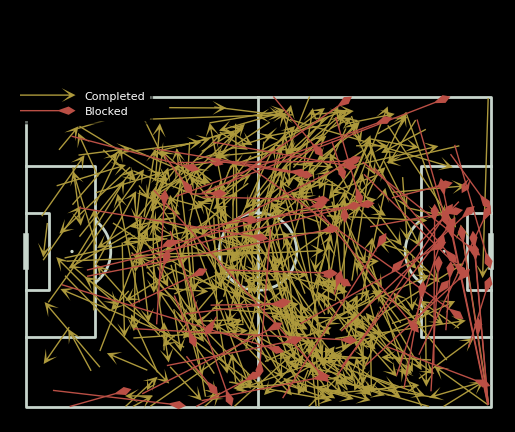

In [35]:
# Team data
team = 'AZ'
teamId = 243
opponent = 'Fortuna'
venue = 'home'

visuals.getTeamTotalPasses(events_df, teamId, team, opponent, pitch_color='#000000')

## Successful box passes

AttributeError: LineCollection.set() got an unexpected keyword argument 'opp_comet'

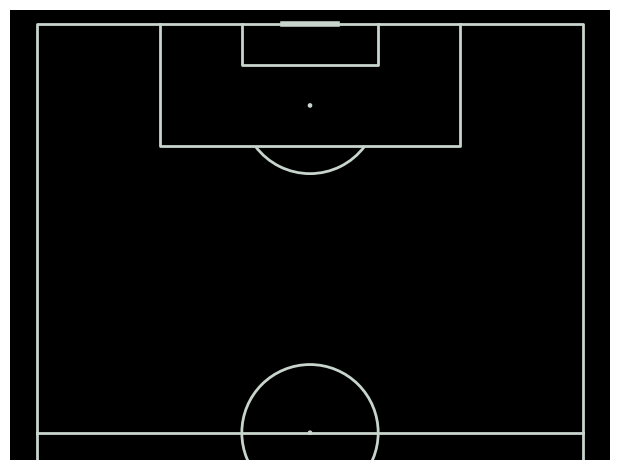

In [36]:
# Team data
team = 'Fortuna'
teamId = 242
opponent = 'AZ'
venue = 'home'

# You can select more cmaps here: https://matplotlib.org/3.1.0/tutorials/colors/colormaps.html
# opp_transparent/opp_comet are manually added by me to this visual, you can change it in visuals.py
# If you get an error regarding 'opp_transparent/opp_comet' you probably haven't replaced pitch.py/linecollection.py file
visuals.getTeamSuccessfulBoxPasses(events_df, teamId, team, pitch_color='#000000', cmap='YlGn')

## All passes network

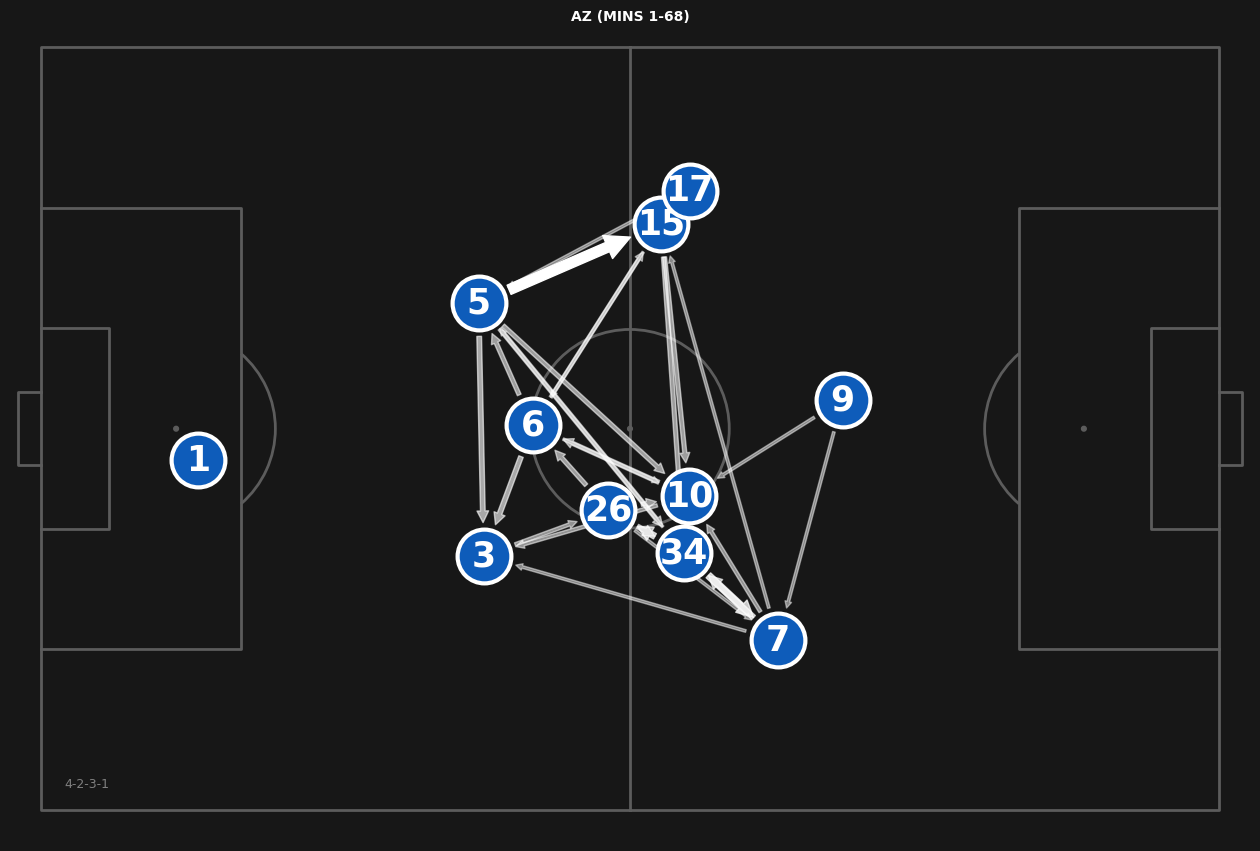

In [47]:
# Team data
team = 'AZ'
teamId = 242
opponent = 'Fortuna'
venue = 'home'

# Create Pass Network     
# you can change marker_label to 'name' as well
fig,ax = plt.subplots(figsize=(16,11))
fig.set_facecolor('#171717')
visuals.createPassNetworks(match_data, events_df, matchId=match_data['matchId'], team='AZ', max_line_width=6, 
                           marker_size=1500, edgewidth=3, dh_arrow_width=25, marker_color='#0e5cba',
                           marker_edge_color='w', shrink=24, ax=ax, kit_no_size=25)

## Progressive passes network

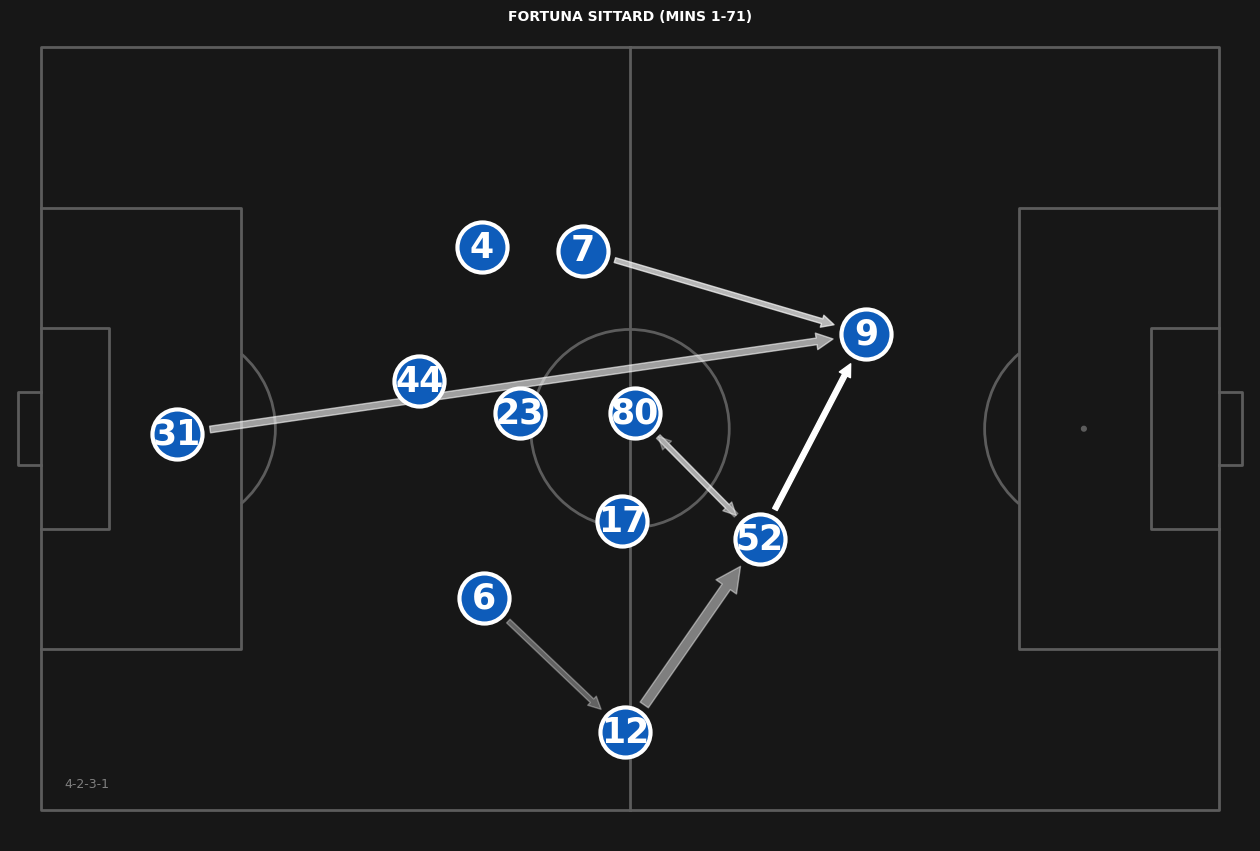

In [50]:
# Team data
team = 'Fortuna Sittard'
teamId = 242
opponent = 'AZ'
venue = 'away'

# Create Progressive Pass Network
# you can change marker_label to 'name' as well
fig,ax = plt.subplots(figsize=(16,11))
fig.set_facecolor('#171717')
visuals.createAttPassNetworks(match_data, events_df, matchId=match_data['matchId'], team='Fortuna Sittard', max_line_width=6, 
                              marker_size=1300, edgewidth=3, dh_arrow_width=25, marker_color='#0e5cba', 
                              marker_edge_color='w', shrink=24, ax=ax, kit_no_size=25)

# Get shotmap

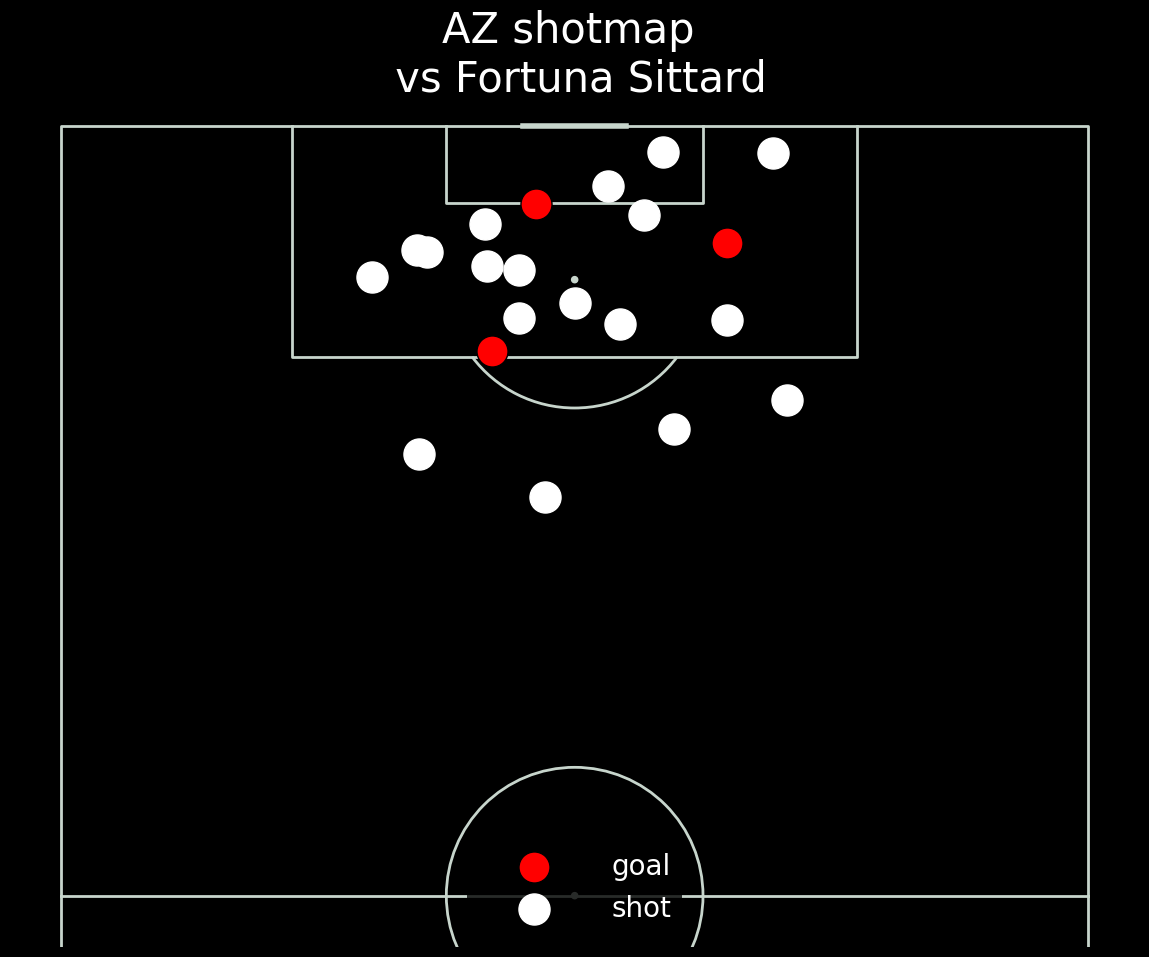

In [41]:
# Team data
team = 'AZ'
teamId = 243
opponent = 'Fortuna'
venue = 'home'

fig,ax = plt.subplots(figsize=(16,11))
visuals.createShotmap(match_data, events_df, team='AZ', pitchcolor='black', shotcolor='white', 
                      goalcolor='red', titlecolor='white', legendcolor='white', marker_size=500, fig=fig, ax=ax)

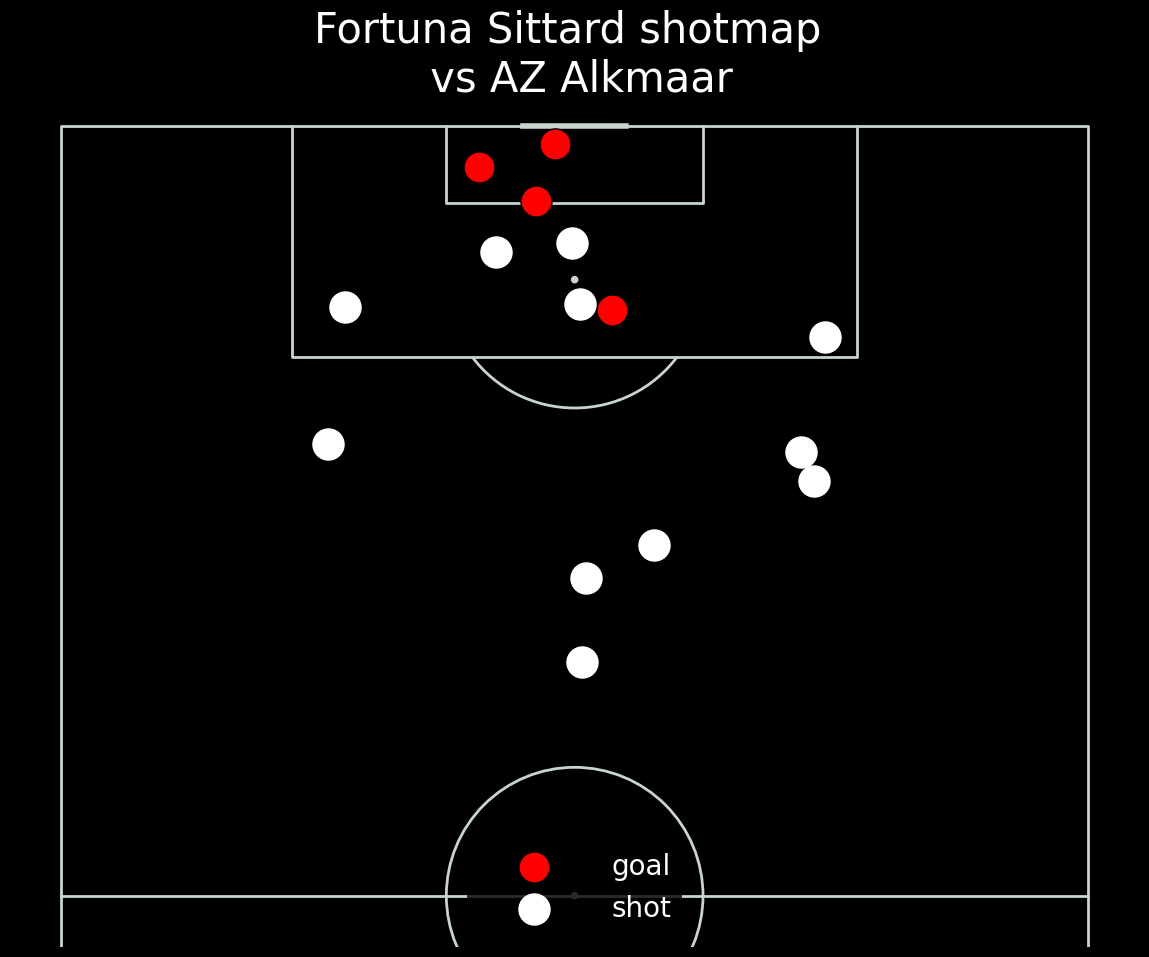

In [46]:
# Team data
team = 'Fortuna Sittard'
teamId = 242
opponent = 'AZ'
venue = 'away'

fig,ax = plt.subplots(figsize=(16,11))
visuals.createShotmap(match_data, events_df, team='Fortuna Sittard', pitchcolor='black', shotcolor='white', 
                      goalcolor='red', titlecolor='white', legendcolor='white', marker_size=500, fig=fig, ax=ax)

# Get PV formation map

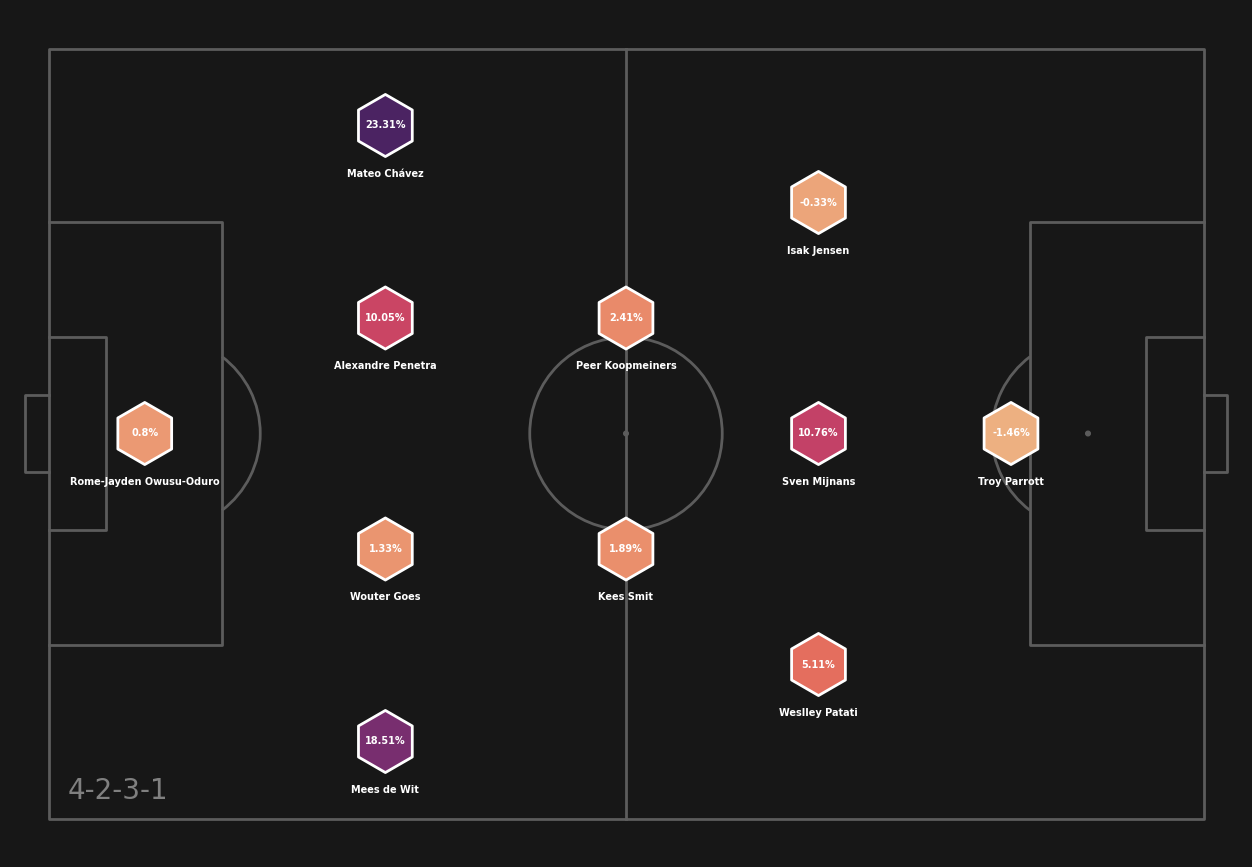

In [29]:
# Team data
team = 'Barcelona'
teamId = 65
opponent = 'Sevilla'
venue = 'home'

# Choose your color palette from here: https://seaborn.pydata.org/tutorial/color_palettes.html
fig,ax = plt.subplots(figsize=(16,11))
fig.set_facecolor('#171717')
visuals.createPVFormationMap(match_data, events_df, team='Barcelona', color_palette=sns.color_palette("flare", as_cmap=True),
                             markerstyle='h', markersize=2000, markeredgewidth=2, labelsize=7, labelcolor='w', ax=ax)